In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, LabelEncoder
from category_encoders import TargetEncoder

pd.set_option('display.max_columns', None)

In [2]:
estudiantes = pd.read_csv('dataset_estudiantes.csv')

estudiantes.head()

,horas_estudio_semanal,nota_anterior,tasa_asistencia,horas_sueno,edad,nivel_dificultad,tiene_tutor,horario_estudio_preferido,estilo_aprendizaje,nota_final,aprobado
0,8.957476,48.830601,86.640182,6.675694,25,Fácil,Sí,Tarde,Lectura/Escritura,84.4,1
1,11.042524,80.825707,83.449655,4.616844,18,Difícil,No,Tarde,NaN,72.0,1
2,4.510776,90.383694,74.623607,7.755246,25,Fácil,No,Mañana,Lectura/Escritura,80.0,1
3,6.647213,81.878257,82.849841,8.592826,23,Fácil,No,NaN,Visual,78.2,1
4,1.000000,66.254179,54.539935,6.671840,21,Medio,No,NaN,Auditivo,66.0,1


Vemos los valores nulos.

In [3]:
nulos = estudiantes.isna().sum()
nulos = nulos[nulos !=0]
nulos

horas_sueno                  150
horario_estudio_preferido    100
estilo_aprendizaje            50
dtype: int64

In [4]:
for col in nulos.index:
    if col in estudiantes.select_dtypes(include='str'):
       print(estudiantes[col].value_counts())

horario_estudio_preferido
Noche     344
Tarde     337
Mañana    219
Name: count, dtype: int64
estilo_aprendizaje
Visual               363
Auditivo             254
Kinestésico          178
Lectura/Escritura    155
Name: count, dtype: int64


Vemos los outliers.

In [5]:
col_num = estudiantes.select_dtypes('number')

col_num.head()

,horas_estudio_semanal,nota_anterior,tasa_asistencia,horas_sueno,edad,nota_final,aprobado
0,8.957476,48.830601,86.640182,6.675694,25,84.4,1
1,11.042524,80.825707,83.449655,4.616844,18,72.0,1
2,4.510776,90.383694,74.623607,7.755246,25,80.0,1
3,6.647213,81.878257,82.849841,8.592826,23,78.2,1
4,1.000000,66.254179,54.539935,6.671840,21,66.0,1


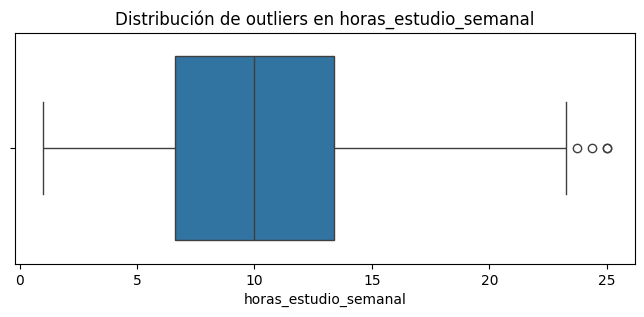

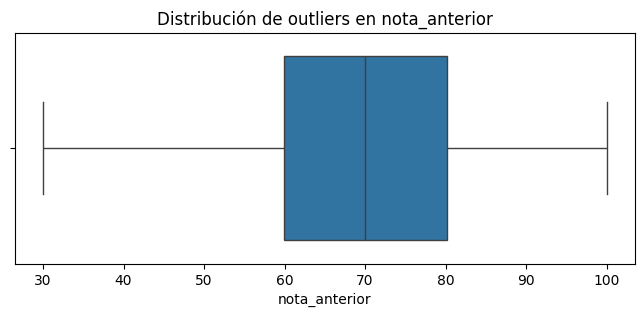

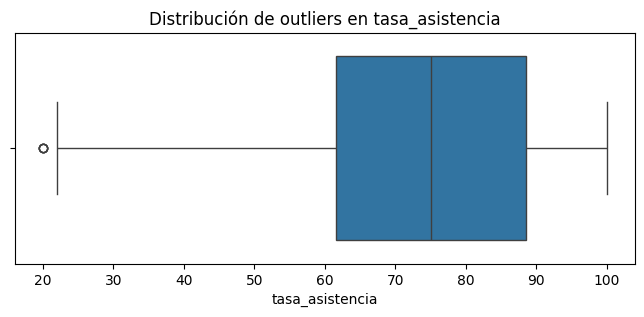

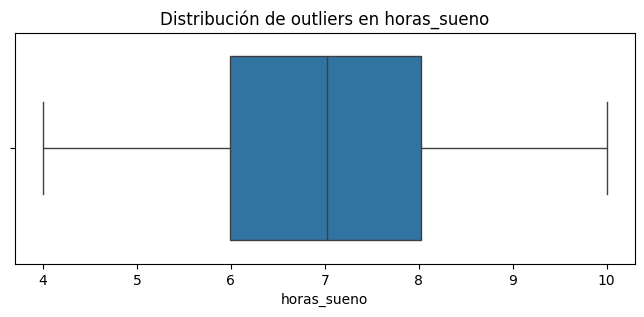

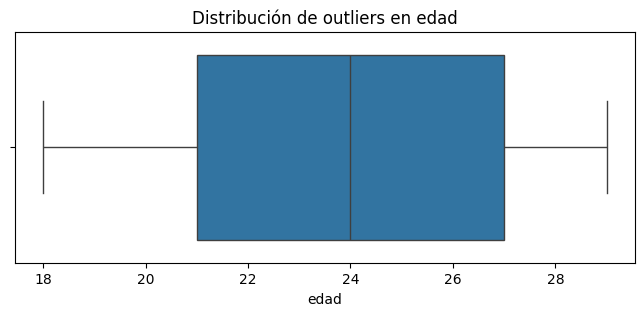

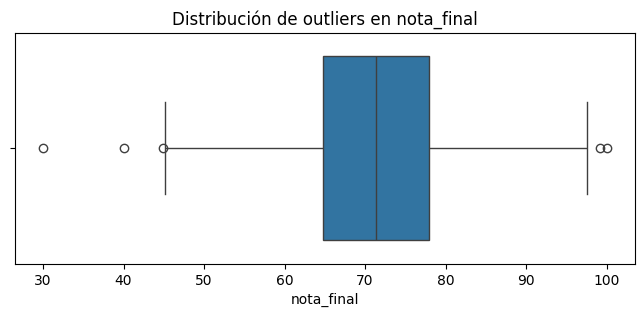

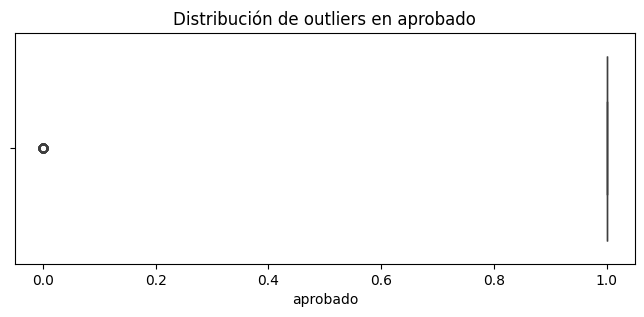

In [6]:
for col in col_num:
    plt.figure(figsize=(8,3))
    sns.boxplot(x=estudiantes[col])
    plt.title(f'Distribución de outliers en {col}')
    plt.show()

Imputación de los nulos.

En las columnas categoricas pondremos desconocido.

In [14]:
col_cat_nulos = ['horario_estudio_preferido','estilo_aprendizaje']
col_cat_nulos

['horario_estudio_preferido', 'estilo_aprendizaje']

In [15]:
val = 'desconocido'

estudiantes[col_cat_nulos] = estudiantes[col_cat_nulos].fillna(val)

En la columna horas de sueño imputaremos con la mediana.

In [18]:
estudiantes['horas_sueno'] = estudiantes['horas_sueno'].fillna(estudiantes['horas_sueno'].median())

In [19]:
estudiantes.isna().sum()

horas_estudio_semanal        0
nota_anterior                0
tasa_asistencia              0
horas_sueno                  0
edad                         0
nivel_dificultad             0
tiene_tutor                  0
horario_estudio_preferido    0
estilo_aprendizaje           0
nota_final                   0
aprobado                     0
dtype: int64

Para regresión la variable objetivo es nota_final.

In [20]:
df_reg = estudiantes.copy() #Hacemos una copia para usar en regresión

tv = 'nota_final'

Vamos a codificar las variables categoricas.

In [29]:
df_reg.head()

,horas_estudio_semanal,nota_anterior,tasa_asistencia,horas_sueno,edad,nivel_dificultad,tiene_tutor,horario_estudio_preferido,estilo_aprendizaje,nota_final,aprobado
0,8.957476,48.830601,86.640182,6.675694,25,Fácil,Sí,Tarde,Lectura/Escritura,84.4,1
1,11.042524,80.825707,83.449655,4.616844,18,Difícil,No,Tarde,desconocido,72.0,1
2,4.510776,90.383694,74.623607,7.755246,25,Fácil,No,Mañana,Lectura/Escritura,80.0,1
3,6.647213,81.878257,82.849841,8.592826,23,Fácil,No,desconocido,Visual,78.2,1
4,1.000000,66.254179,54.539935,6.671840,21,Medio,No,desconocido,Auditivo,66.0,1


In [28]:
col_cat  = df_reg.select_dtypes(include='str').columns.to_list()

col_cat

['nivel_dificultad',
 'tiene_tutor',
 'horario_estudio_preferido',
 'estilo_aprendizaje']

In [30]:
for col in col_cat:
    print(df_reg[col].value_counts())

nivel_dificultad
Medio      504
Fácil      313
Difícil    183
Name: count, dtype: int64
tiene_tutor
No    597
Sí    403
Name: count, dtype: int64
horario_estudio_preferido
Noche          344
Tarde          337
Mañana         219
desconocido    100
Name: count, dtype: int64
estilo_aprendizaje
Visual               363
Auditivo             254
Kinestésico          178
Lectura/Escritura    155
desconocido           50
Name: count, dtype: int64


Usaremos one_hot_encoder para las columnas nivel_dificultad y tiene_tutor.
Y target_encoding para horario_estudio y estilo_aprendizaje.

In [32]:
onehot_cols = ['nivel_dificultad', 'tiene_tutor']
target_cols = ['horario_estudio_preferido', 'estilo_aprendizaje']

In [ ]:
onehot_encoder = OneHotEncoder(drop=None, sparse_output=False, handle_unknown='ignore') # Configuramos el codificador.

onehot_encoded = onehot_encoder.fit_transform(df_reg[onehot_cols]) # Lo aplicamos a las columnas elegidas.

columnas_onehot = onehot_encoder.get_feature_names_out() # Guardamos el nombre de las columnas.

df_onehot = pd.DataFrame(onehot_encoded, columns=columnas_onehot, index=df_reg.index) # Creamos un dataframe con la codificación.

df_reg = pd.concat([df_reg.drop(columns=onehot_cols), df_onehot], axis=1) # Lo concatenamos con df_reg borrando las columnas sin codificar.

In [34]:
# Aplicamos target_encoder, usamos smoothing para suavizar los datos desconocidos, ya que hay pocos valores.
target_encoder = TargetEncoder(cols=target_cols, smoothing=10) 
df_reg[target_cols] = target_encoder.fit_transform(df_reg[target_cols], df_reg[tv])

In [35]:
df_reg.head()

,horas_estudio_semanal,nota_anterior,tasa_asistencia,horas_sueno,edad,horario_estudio_preferido,estilo_aprendizaje,nota_final,aprobado,nivel_dificultad_Difícil,nivel_dificultad_Fácil,nivel_dificultad_Medio,tiene_tutor_No,tiene_tutor_Sí
0,8.957476,48.830601,86.640182,6.675694,25,71.710089,72.594837,84.4,1,0.0,1.0,0.0,0.0,1.0
1,11.042524,80.825707,83.449655,4.616844,18,71.710089,68.839539,72.0,1,1.0,0.0,0.0,1.0,0.0
2,4.510776,90.383694,74.623607,7.755246,25,71.598174,72.594837,80.0,1,0.0,1.0,0.0,1.0,0.0
3,6.647213,81.878257,82.849841,8.592826,23,72.370688,70.526997,78.2,1,0.0,1.0,0.0,1.0,0.0
4,1.000000,66.254179,54.539935,6.671840,21,72.370688,71.816929,66.0,1,0.0,0.0,1.0,1.0,0.0


Hacemos el escalado de los datos para igualar su importancia.

In [36]:
scaler = MinMaxScaler()
df_reg[df_reg.drop(columns=[tv]).columns] = scaler.fit_transform(df_reg.drop(columns=[tv]))

In [37]:
df_reg.head()

,horas_estudio_semanal,nota_anterior,tasa_asistencia,horas_sueno,edad,horario_estudio_preferido,estilo_aprendizaje,nota_final,aprobado,nivel_dificultad_Difícil,nivel_dificultad_Fácil,nivel_dificultad_Medio,tiene_tutor_No,tiene_tutor_Sí
0,0.331561,0.269009,0.833002,0.445949,0.636364,0.577230,1.000000,84.4,1.0,0.0,1.0,0.0,0.0,1.0
1,0.418439,0.726082,0.793121,0.102807,0.000000,0.577230,0.000000,72.0,1.0,1.0,0.0,0.0,1.0,0.0
2,0.146282,0.862624,0.682795,0.625874,0.636364,0.505606,1.000000,80.0,1.0,0.0,1.0,0.0,1.0,0.0
3,0.235301,0.741118,0.785623,0.765471,0.454545,1.000000,0.449354,78.2,1.0,0.0,1.0,0.0,1.0,0.0
4,0.000000,0.517917,0.431749,0.445307,0.272727,1.000000,0.792851,66.0,1.0,0.0,0.0,1.0,1.0,0.0


In [38]:
df_reg.to_csv('df_regresion.csv') # Guardamos el dataframe para regresión.

Para clasificación la variable objetivo es aprobado

In [40]:
df_clas = estudiantes.copy()

tv = 'aprobado'

In [41]:
onehot_cols = ['nivel_dificultad', 'tiene_tutor']
target_cols = ['horario_estudio_preferido', 'estilo_aprendizaje']

Utilizamos lo mismo que en regresión con la nueva variante.

In [42]:
onehot_encoder = OneHotEncoder(drop=None, sparse_output=False, handle_unknown='ignore') 
onehot_encoded = onehot_encoder.fit_transform(df_clas[onehot_cols]) 
columnas_onehot = onehot_encoder.get_feature_names_out()
df_onehot = pd.DataFrame(onehot_encoded, columns=columnas_onehot, index=df_clas.index)
df_clas = pd.concat([df_clas.drop(columns=onehot_cols), df_onehot], axis=1) 

In [ ]:
target_encoder = TargetEncoder(cols=target_cols, smoothing=10) 
df_clas[target_cols] = target_encoder.fit_transform(df_clas[target_cols], df_clas[tv])

In [44]:
scaler = MinMaxScaler()
df_clas[df_clas.columns] = scaler.fit_transform(df_clas)

In [45]:
df_clas.head()

,horas_estudio_semanal,nota_anterior,tasa_asistencia,horas_sueno,edad,horario_estudio_preferido,estilo_aprendizaje,nota_final,aprobado,nivel_dificultad_Difícil,nivel_dificultad_Fácil,nivel_dificultad_Medio,tiene_tutor_No,tiene_tutor_Sí
0,0.331561,0.269009,0.833002,0.445949,0.636364,0.463128,1.000000,0.777143,1.0,0.0,1.0,0.0,0.0,1.0
1,0.418439,0.726082,0.793121,0.102807,0.000000,0.463128,0.000000,0.600000,1.0,1.0,0.0,0.0,1.0,0.0
2,0.146282,0.862624,0.682795,0.625874,0.636364,0.561063,1.000000,0.714286,1.0,0.0,1.0,0.0,1.0,0.0
3,0.235301,0.741118,0.785623,0.765471,0.454545,1.000000,0.465920,0.688571,1.0,0.0,1.0,0.0,1.0,0.0
4,0.000000,0.517917,0.431749,0.445307,0.272727,1.000000,0.758538,0.514286,1.0,0.0,0.0,1.0,1.0,0.0


In [47]:
df_clas.to_csv('df_clasificacion.csv')